# 03 Aggregation Visualization

Visualization truc tiep tu Gold layer tren HDFS.

In [1]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt

spark = (
    SparkSession.builder
    .appName('AggregationVizNotebook')
    .master('local[*]')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')

BASE = 'hdfs://namenode:9000/nyc_taxi/gold'
BY_HOUR = f'{BASE}/aggregated_by_time/by_hour'
BY_PAYMENT = f'{BASE}/aggregated_by_vendor/by_payment'

df_hour = spark.read.parquet(BY_HOUR).orderBy('pickup_hour').toPandas()
df_payment = spark.read.parquet(BY_PAYMENT).toPandas()

df_hour.head(), df_payment.head()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/30 11:08:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/30 11:08:56 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


(   pickup_hour  total_trips  total_passengers  avg_distance_miles  avg_fare  \
 0            0        50801             68281                2.54     14.64   
 1            1        34633             46771                2.44     14.11   
 2            2        24107             32586                2.42     13.94   
 3            3        15928             21379                2.48     13.94   
 4            4         9945             12778                2.79     14.92   
 
    total_revenue  avg_tip_pct  avg_duration_min  avg_speed_mph  
 0     1185330.38        22.66             11.76          12.62  
 1      784053.87        22.61             11.24          12.64  
 2      540692.77        22.65             10.97          12.76  
 3      355219.18        22.10             10.71          13.39  
 4      228540.83        20.56             11.49          14.49  ,
    payment_type  total_trips  total_revenue  avg_fare  avg_tip  avg_tip_pct  \
 0             1      1929742    43957562

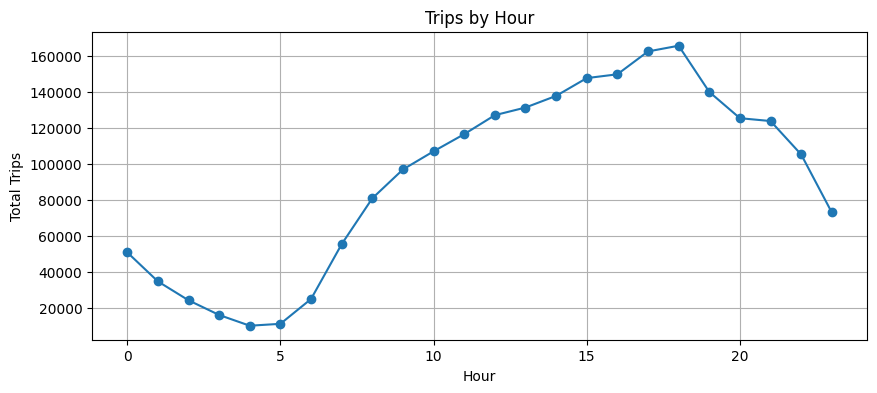

In [2]:
plt.figure(figsize=(10, 4))
plt.plot(df_hour['pickup_hour'], df_hour['total_trips'], marker='o')
plt.title('Trips by Hour')
plt.xlabel('Hour')
plt.ylabel('Total Trips')
plt.grid(True)
plt.show()

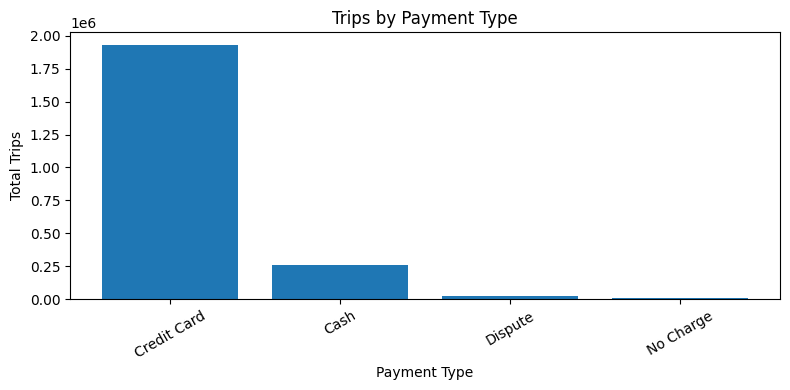

In [3]:
plt.figure(figsize=(8, 4))
x = df_payment['payment_name'] if 'payment_name' in df_payment.columns else df_payment['payment_type'].astype(str)
plt.bar(x, df_payment['total_trips'])
plt.title('Trips by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Total Trips')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()